In [1]:
from DatabaseCreator import DatabaseCreator
import CJDH_local_settings

#Run Database Creator
if __name__ == "__main__":
    db_creator = DatabaseCreator(db_settings=CJDH_local_settings.local_settings['FPL_Points_Predictor'])
    fpl_engine = db_creator.get_engine_for("fpl_data_analysis")

In [2]:
# Run SELECT and get results
pgw = db_creator.run_sql("""SELECT *
                        FROM playergw_transformed
                          """)
pgw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 147334 entries, 0 to 147333
Columns: 430 entries, player_name_id to saves_elo_p90sq_10
dtypes: float64(425), object(5)
memory usage: 483.3+ MB


In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

def classify_players(df, position, features, cluster_labels, 
                     min_minutes=500, n_clusters=2, random_state=42):
    """
    Classify players within a position using PCA and K-Means clustering.
    
    Parameters:
    -----------
    df : DataFrame
        The full player gameweek dataframe
    position : str
        Position to filter (e.g., 'MID', 'DEF', 'FWD')
    features : list
        List of feature names to use for classification
        Example: ['goals_scored', 'assists', 'tackles', ...]
    cluster_labels : list
        Labels for clusters, ordered by attacking metric
        Example: ['Defensive', 'Offensive'] or ['Central', 'Attacking']
    min_minutes : int
        Minimum minutes played to include player
    n_clusters : int
        Number of clusters (default: 2)
    random_state : int
        Random state for reproducibility
        
    Returns:
    --------
    tuple : (updated_df, player_stats, pca, kmeans)
        - updated_df: Original df with new classification column
        - player_stats: Aggregated player statistics with clusters
        - pca: Fitted PCA object
        - kmeans: Fitted KMeans object
    """
    
    # Filter for specified position
    position_players = df[df['position'] == position].copy()
    
    if len(position_players) == 0:
        print(f"No players found for position: {position}")
        return df, None, None, None
    
    # Create aggregation dict: sum for all features
    agg_dict = {feat: 'sum' for feat in features if feat in position_players.columns}
    
    # Aggregate statistics per player
    player_stats = position_players.groupby('player_name_id').agg(agg_dict).dropna()
    
    # Filter by minimum playing time
    player_stats = player_stats[player_stats['minutes'] >= min_minutes]
    
    # Convert features to per 90 minutes (except 'minutes' itself)
    features_to_convert = [f for f in features if f != 'minutes' and f in player_stats.columns]
    for feature in features_to_convert:
        player_stats[f'{feature}_per90'] = (player_stats[feature] / player_stats['minutes']) * 90
    
    # Update feature list to use per90 versions
    per90_features = [f'{f}_per90' if f != 'minutes' else f for f in features if f in player_stats.columns or f'{f}_per90' in player_stats.columns]
    
    if len(player_stats) < n_clusters:
        print(f"Not enough players with {min_minutes}+ minutes: {len(player_stats)}")
        return df, None, None, None
    
    print(f"Number of {position} players analyzed: {len(player_stats)}")
    
    # Select only per90 features for clustering
    clustering_features = [f for f in per90_features if f in player_stats.columns]
    X = player_stats[clustering_features]
    
    # Standardize features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Apply PCA for dimension reduction
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    
    print(f"\nExplained variance ratio: {pca.explained_variance_ratio_}")
    print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.2%}")
    
    # Apply K-Means clustering
    kmeans = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=10)
    clusters = kmeans.fit_predict(X_pca)
    
    # Add results to dataframe
    player_stats['cluster'] = clusters
    player_stats['PC1'] = X_pca[:, 0]
    player_stats['PC2'] = X_pca[:, 1]
    
    # Determine cluster labels based on attacking metrics
    # Use first attacking feature in the config to determine order
    attacking_features = ['goals_scored_per90', 'assists_per90', 'expected_goals_per90', 'expected_goal_involvements_per90']
    sort_feature = None
    for feat in attacking_features:
        if feat in player_stats.columns:
            sort_feature = feat
            break
    
    if sort_feature:
        cluster_profiles = player_stats.groupby('cluster')[[sort_feature]].mean()
        print(f"\nCluster Profiles (sorted by {sort_feature}):")
        cluster_order = cluster_profiles[sort_feature].sort_values(ascending=False).index.tolist()
    else:
        cluster_order = list(range(n_clusters))
    
    # Map clusters to labels
    cluster_mapping = {cluster_order[i]: cluster_labels[i] for i in range(n_clusters)}
    player_stats['player_type'] = player_stats['cluster'].map(cluster_mapping)
    
    # Create interactive visualization with Plotly
    plot_df = player_stats.reset_index()
    
    # Create hover text with key stats (use per90 versions)
    hover_cols = []
    potential_hover = ['goals_scored_per90', 'assists_per90', 'tackles_per90', 'clean_sheets']
    for col in potential_hover:
        if col in plot_df.columns:
            hover_cols.append(col)
    hover_cols.append('minutes')  # Always include total minutes
    
    # Create custom hover data dict
    hover_data_dict = {
        'PC1': ':.2f',
        'PC2': ':.2f',
        'player_type': True,
    }
    for col in hover_cols:
        if col in plot_df.columns:
            hover_data_dict[col] = ':.2f'
    
    # Interactive scatter plot
    fig = px.scatter(
        plot_df,
        x='PC1',
        y='PC2',
        color='player_type',
        hover_name='player_name_id',
        hover_data=hover_data_dict,
        title=f'{position} Classification (PCA + K-Means) - Per 90 Metrics',
        labels={
            'PC1': f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)',
            'PC2': f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)',
            'player_type': 'Type'
        },
        color_discrete_sequence=px.colors.qualitative.Set2
    )
    
    fig.update_traces(marker=dict(size=8, opacity=0.7))
    fig.update_layout(
        height=600,
        hovermode='closest',
        plot_bgcolor='white',
        xaxis=dict(showgrid=True, gridcolor='lightgray'),
        yaxis=dict(showgrid=True, gridcolor='lightgray')
    )
    
    fig.show()
    
    # Also create static plot for feature importance
    components_df = pd.DataFrame(
        pca.components_.T,
        columns=['PC1', 'PC2'],
        index=clustering_features
    )
    components_df['abs_PC1'] = np.abs(components_df['PC1'])
    components_df = components_df.sort_values('abs_PC1', ascending=True)
    
    fig2, ax = plt.subplots(figsize=(10, 6))
    ax.barh(range(len(components_df)), components_df['PC1'])
    ax.set_yticks(range(len(components_df)))
    ax.set_yticklabels(components_df.index)
    ax.set_xlabel('PC1 Loading')
    ax.set_title('Feature Contributions to PC1 (Per 90 Metrics)')
    ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    ax.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()
    
    # Print classification summary
    print("\n" + "="*60)
    print(f"{position} CLASSIFICATION SUMMARY")
    print("="*60)
    for label in cluster_labels:
        count = (player_stats['player_type'] == label).sum()
        print(f"\n{label}: {count}")
    
    # Show top players in each category
    for i, label in enumerate(cluster_labels):
        print(f"\nTop 10 {label} (by {sort_feature if sort_feature else 'minutes'}):")
        category_players = player_stats[player_stats['player_type'] == label]
        
        # Display per90 stats
        display_cols = ['goals_scored_per90', 'assists_per90', 'minutes']
        if 'tackles_per90' in player_stats.columns:
            display_cols.insert(2, 'tackles_per90')
        if 'clean_sheets' in player_stats.columns:
            display_cols.insert(3, 'clean_sheets')
        
        available_cols = [col for col in display_cols if col in player_stats.columns]
        sort_col = sort_feature if sort_feature else 'minutes'
        print(category_players.nlargest(10, sort_col)[available_cols])
    
    # Merge classification back to original dataframe
    player_classification = player_stats[['player_type']].reset_index()
    df = df.merge(player_classification, on='player_name_id', how='left', suffixes=('', '_new'))
    
    # Handle column naming
    if 'player_type_new' in df.columns:
        df['player_type'] = df['player_type_new'].fillna(df.get('player_type', ''))
        df = df.drop(columns=['player_type_new'])
    
    print(f"\n✓ Classification complete! New column 'player_type' added to dataframe")
    
    return df, player_stats, pca, kmeans


In [4]:
pgw.columns.to_list()

['player_name_id',
 'element',
 'season',
 'value',
 'event',
 'minutes',
 'total_points',
 'team_elo',
 'opp_team_elo',
 'position',
 'goals_scored',
 'bonus',
 'bps',
 'clean_sheets',
 'goals_conceded',
 'was_home',
 'expected_goals',
 'expected_assists',
 'expected_goal_involvements',
 'expected_goals_conceded',
 'team_name',
 'opp_team_name',
 'cbi',
 'defensive_contribution',
 'recoveries',
 'tackles',
 'saves',
 'player_season_minutes_total',
 'player_season_points_per90',
 'points_per90',
 'expected_goals_per90',
 'expected_assists_per90',
 'expected_goals_conceded_per90',
 'saves_per90',
 'bps_per90',
 'bonus_per90',
 'cbi_per90',
 'defensive_contribution_per90',
 'recoveries_per90',
 'tackles_per90',
 'elo_diff',
 'xgoal_involvements_x_defensive_cont_p90_at',
 'xgoal_involvements_x_defensive_cont_at',
 'xgoal_involvements_x_defensive_cont_p90_3',
 'xgoal_involvements_x_defensive_cont_3',
 'xgoal_involvements_x_defensive_cont_elo_p90_3',
 'xgoal_involvements_x_defensive_cont_p9

Number of MID players analyzed: 478

Explained variance ratio: [0.31228315 0.23331777]
Total variance explained: 54.56%

Cluster Profiles (sorted by goals_scored_per90):


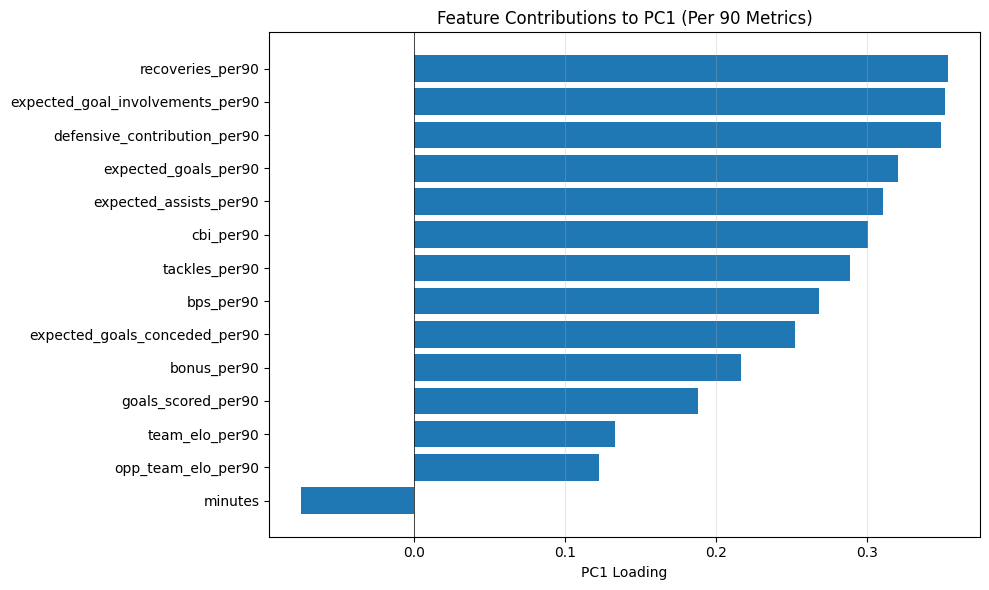


MID CLASSIFICATION SUMMARY

Offensive: 427

Defensive: 51

Top 10 Offensive (by goals_scored_per90):
                         goals_scored_per90  tackles_per90  minutes
player_name_id                                                     
Gareth Bale                        1.178010       0.000000    764.0
Donyell Malen                      0.804598       0.459770    783.0
Richarlison de Andrade             0.697674       0.000000   1419.0
Diogo Teixeira da Silva            0.638298       0.000000   2256.0
Mohamed Salah                      0.630391       0.145924  15419.0
Diogo Jota                         0.615480       0.000000   3217.0
Rodrigo Moreno                     0.611925       0.000000   1912.0
Heung-Min Son                      0.599159       0.000000   5708.0
Anwar El Ghazi                     0.548173       0.000000   1806.0
Cole Palmer                        0.537990       0.056630   6357.0

Top 10 Defensive (by goals_scored_per90):
                                 goals_

In [5]:

# =============================================================================
# EXAMPLE 1: Classify Midfielders (Defensive vs Offensive)
# =============================================================================

features = ['minutes',
 'team_elo',
 'opp_team_elo',
 'goals_scored',
 'bonus',
 'bps',
 'expected_goals',
 'expected_assists',
 'expected_goal_involvements',
 'expected_goals_conceded',
 'cbi',
 'defensive_contribution',
 'recoveries',
 'tackles'
]

pgw, mid_stats, mid_pca, mid_kmeans = classify_players(
    df=pgw,
    position='MID',
    features=features,
    cluster_labels=['Offensive', 'Defensive'],  # Order: most attacking first
    min_minutes=500
)

Number of DEF players analyzed: 394

Explained variance ratio: [0.33027105 0.19653748]
Total variance explained: 52.68%

Cluster Profiles (sorted by goals_scored_per90):


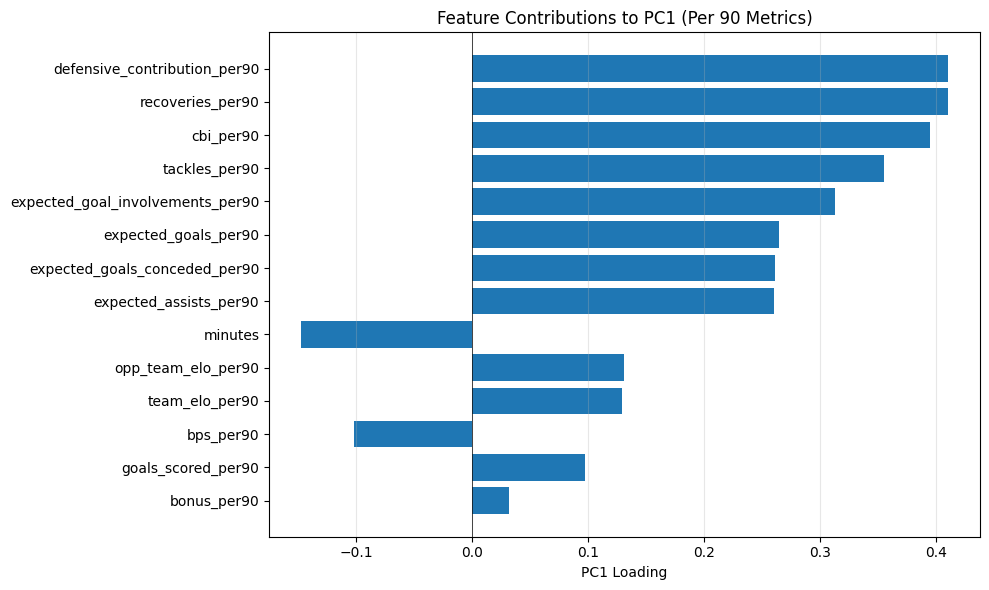


DEF CLASSIFICATION SUMMARY

Attacking: 54

Central: 340

Top 10 Attacking (by goals_scored_per90):
                        goals_scored_per90  tackles_per90  minutes
player_name_id                                                    
Maxim De Cuyper                   0.257143       1.285714    700.0
Nicolò Savona                     0.215827       1.834532    834.0
Daniel Muñoz Mejía                0.214286       2.214286   1260.0
Daniel Ballard                    0.174927       3.236152   1029.0
Josh Acheampong                   0.174419       0.348837    516.0
Joško Gvardiol                    0.173410       0.953757   1038.0
Jaka Bijol                        0.169173       5.582707    532.0
Malick Thiaw                      0.166359       1.081331   1082.0
Jurriën Timber                    0.139860       2.797203   1287.0
Santiago Ignacio Bueno            0.135542       3.117470    664.0

Top 10 Central (by goals_scored_per90):
                   goals_scored_per90  tackles_per90  m

In [6]:

# =============================================================================
# EXAMPLE 2: Classify Defenders (Attacking vs Central)
# =============================================================================
pgw, def_stats, def_pca, def_kmeans = classify_players(
    df=pgw,
    position='DEF',
    features=features,
    cluster_labels=['Attacking', 'Central'],  # Order: most attacking first
    min_minutes=500
)